# Shor's Algorithm – the *classical* part

Shor's algorithm reduces integer factoring to **finding the period of `a^z mod N`**. That period-finding sub-routine is what the quantum computer accelerates. Everything *around* it is plain classical number theory:

1. Pick a random `a` co-prime to `N`.
2. Find the period `r` of `f(z) = a^z mod N`.
3. If `r` is even and `a^(r/2) ≢ -1 mod N`, then `gcd(a^(r/2) ± 1, N)` are non-trivial factors of `N`.

This notebook walks through the **classical** steps so you can see what the quantum part is actually replacing.

> No Qiskit code is used here, so nothing needs updating for Qiskit 2.x. The next notebook (`QX13`) shows the *quantum* version of the same algorithm.

In [1]:
import math
import matplotlib.pyplot as mpl
import numpy as np

### Step 1 – Pick the number to factor and a random base

We try to factor `N`. We also pick a base `a < N` co-prime to `N`.

In [2]:
#N = 15
#a = 13

N = 21
a = 2

### Step 2 – Cheap classical sanity check

If `gcd(a, N) ≠ 1` we already have a factor of N and there's nothing for the quantum part to do. We only continue if the gcd is `1`.

In [3]:
math.gcd(a, N)

1

### Step 3 – Find the period of `a^z mod N`

The function `f(z) = a^z mod N` is **periodic**. The period `r` is the smallest positive integer with `a^r mod N = 1`. Plot it and you'll see the saw-tooth pattern that gives the algorithm its kick.

> On a classical computer this step is the **expensive** one. On a quantum computer Shor's algorithm replaces it with a Quantum Fourier Transform – that is the whole point of the speed-up.

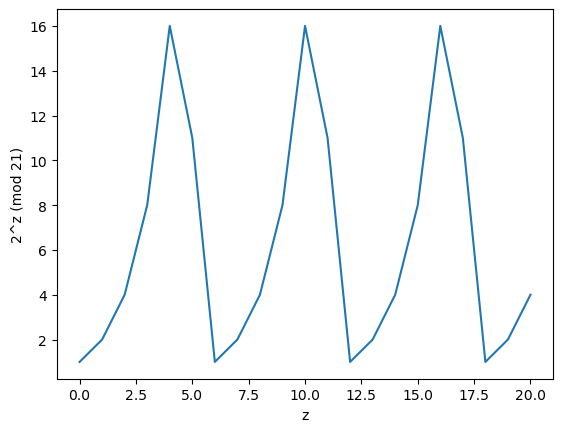

In [4]:
z = list(range(N))
y = [a**z0 % N for z0 in z]

mpl.plot(z,y)
mpl.xlabel('z')
mpl.ylabel(f'{a}^z (mod {N})')
mpl.show()

### Step 4 – Reading the period off the plot

The period `r` is the smallest positive integer such that `a^r ≡ 1 (mod N)`. We just look up the first `1` in the `y` list (after index 0).

In [5]:
r = z[y[1:].index(1)+1]
print(r)

6


### Step 5 – From the period to the factors

If `r` is **even**, then `x = a^(r/2) mod N` is a square root of 1 mod N, and `gcd(x ± 1, N)` are non-trivial factors of N (assuming `x + 1 ≠ 0 mod N`).

If `r` is **odd** (or the post-conditions fail) we have to pick a new `a` and try again – something the original Shor's paper handles by simply restarting.

In [6]:
if r % 2 == 0:
    x = (a**(r/2.)) % N
    print(f'x: {x}')
    if((x+1) % N) != 0:
        print(math.gcd((int(x)+1),N), math.gcd((int(x)-1),N))
    else:
        print('x+1 is 0 (mod N)')
else:
    print('r is odd')

x: 8.0
3 7
